In this section: we are loading the dataset from the Nummpy File such that it contains jet particle information(X) and their corresonding labels(Y).

In [ ]:
import numpy as np

data = np.load('QG_jets.npz') 

X = data['X'] 
y = data['y']

print(f"Data shape: {X.shape}") 

Data shape: (100000, 139, 4)


In this Section: we are computing basic jet properties and visualising the difference between the quark(y = 1) and glueon(y= 0).
                 we are also making a mask to identify valid particles in each jet using momentum (since there should be a presence i.e. the value shall be >0... i.e. Pt > 0).
                 we then are summing the various multiplicites to get the total number of particles per jet.
                 we finally proceed to plot histograms to compare multiplicity distribution.

2660906
1669999


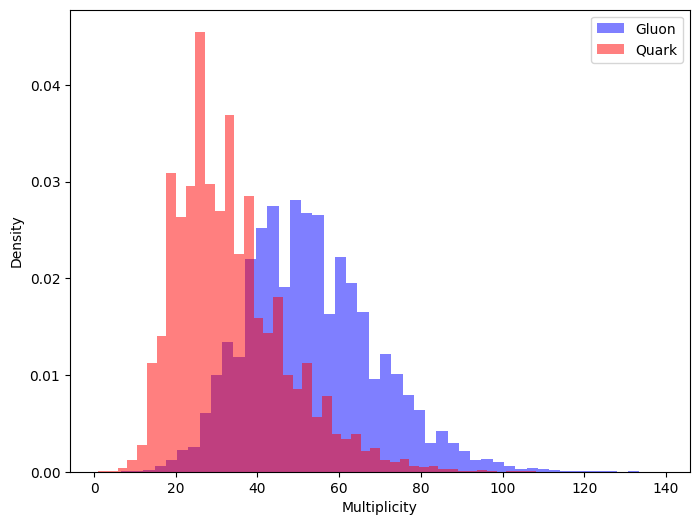

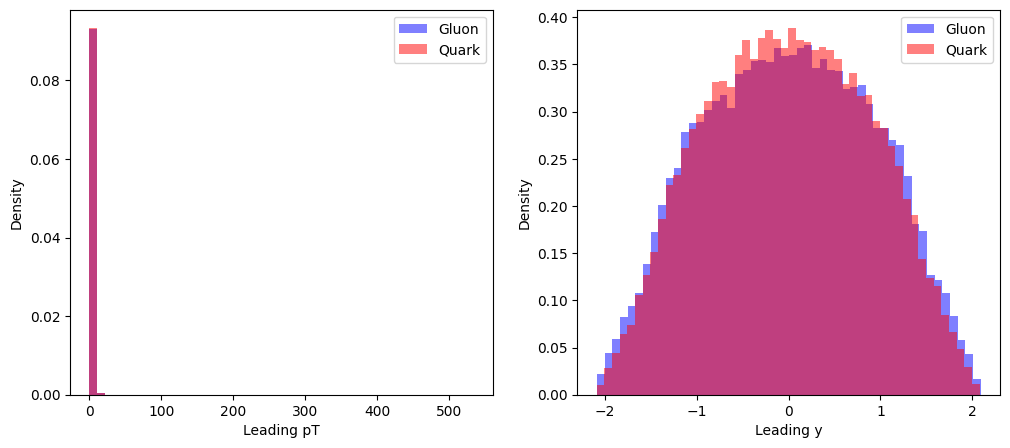

In [3]:
import numpy as np
import matplotlib.pyplot as plt

mask = X[:, :, 0] > 0
multiplicities = np.sum(mask, axis=1)

gluon_mult = multiplicities[y == 0]
quark_mult = multiplicities[y == 1]

print(np.sum(gluon_mult))
print(np.sum(quark_mult))

plt.figure(figsize=(8, 6))
plt.hist(gluon_mult, bins=50, alpha=0.5, label='Gluon', color='blue', density=True)
plt.hist(quark_mult, bins=50, alpha=0.5, label='Quark', color='red', density=True)
plt.xlabel('Multiplicity')
plt.ylabel('Density')
plt.legend()
plt.show()

leading_pt = X[:, 0, 0]
leading_y = X[:, 0, 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(leading_pt[y == 0], bins=50, alpha=0.5, label='Gluon', color='blue', density=True)
plt.hist(leading_pt[y == 1], bins=50, alpha=0.5, label='Quark', color='red', density=True)
plt.xlabel('Leading pT')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(leading_y[y == 0], bins=50, alpha=0.5, label='Gluon', color='blue', density=True)
plt.hist(leading_y[y == 1], bins=50, alpha=0.5, label='Quark', color='red', density=True)
plt.xlabel('Leading y')
plt.ylabel('Density')
plt.legend()

plt.show()

In this Section: we are calculating the Mass of jet. We get the mass of Jet by sqrt(e2 - total px2 - total py2 - total pz2) where px and py are the momentum component along plane. pz is the longitudinal momentum. E is the total energy of particle. using the formula and the components we are calculating the mass of the jet.

In [6]:
px = X[:, :, 0] * np.cos(X[:, :, 2])
py = X[:, :, 0] * np.sin(X[:, :, 2])
pz = X[:, :, 0] * np.sinh(X[:, :, 1])
e_particles = X[:, :, 0] * np.cosh(X[:, :, 1])

total_px = np.sum(px, axis=1)
total_py = np.sum(py, axis=1)
total_pz = np.sum(pz, axis=1)
total_e  = np.sum(e_particles, axis=1)

m2 = total_e**2 - (total_px**2 + total_py**2 + total_pz**2)

jet_mass = np.sqrt(np.maximum(m2, 0))


In this Section: we are comparing and visualising the mass distribution for both gluon jet and quark jet.

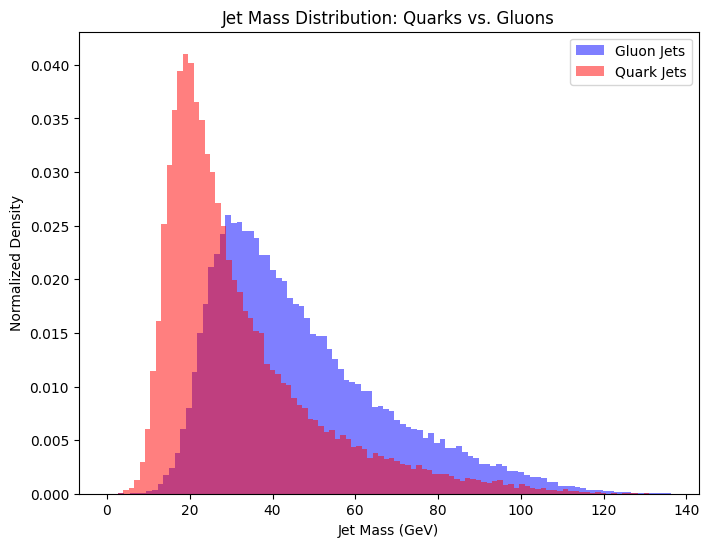

In [7]:
import matplotlib.pyplot as plt

gluon_mass = jet_mass[y == 0]
quark_mass = jet_mass[y == 1]

plt.figure(figsize=(8, 6))
plt.hist(gluon_mass, bins=100, alpha=0.5, label='Gluon Jets', color='blue', density=True)
plt.hist(quark_mass, bins=100, alpha=0.5, label='Quark Jets', color='red', density=True)
plt.xlabel('Jet Mass (GeV)')
plt.ylabel('Normalized Density')
plt.title('Jet Mass Distribution: Quarks vs. Gluons')
plt.legend()
plt.show()

In this Section: We are trying to change our frame of refernce to that of moving inside/same with the jet. Doing so we can handle the earlier possiblity of our data getting blurry by using the Lorentz Factor (gamma). (we are using the conservation of energy and momentum). since now we are inside the jet frame, the sum of new momenta should be 0 (i.e. it should be in rest with respect to us.). 

In [13]:
bx = total_px / total_e
by = total_py / total_e
bz = total_pz / total_e

beta2 = bx**2 + by**2 + bz**2
beta2 = np.clip(beta2, 0, 0.999999) 

gamma = 1.0 / np.sqrt(1.0 - beta2)

bx_r = bx[:, np.newaxis]
by_r = by[:, np.newaxis]
bz_r = bz[:, np.newaxis]
g_r = gamma[:, np.newaxis]
b2_r = beta2[:, np.newaxis]

bp = bx_r * px + by_r * py + bz_r * pz

In this Section: We are using the lorentz Factor to actually re-calculate each particle's energy. we calculate a scaling factor to combine both jet's velocity(beta) and lorentz factor(gamma).

In [14]:
E_prime = g_r * (e_particles - bp)

factor = ((g_r - 1) * bp / np.maximum(b2_r, 1e-10)) - (g_r * e_particles)

px_prime = px + (factor * bx_r)
py_prime = py + (factor * by_r)
pz_prime = pz + (factor * bz_r)

# Verification Check
print(f"Total E' for Jet 0: {np.sum(E_prime[0]):.4f}")
print(f"Original Jet Mass M: {jet_mass[0]:.4f}")

Total E' for Jet 0: 16.1084
Original Jet Mass M: 16.1084


In this Section: we are calculating the boosted traverse momentum (pt new) and the boosted rapidity (y new). we are also taking care of zero padding (by np.where) because some of our data contain completly by zero padding.

In [18]:
# 1. Boosted Transverse Momentum (pT') - This is safe as is
pt_boosted = np.sqrt(px_prime**2 + py_prime**2)

# 2. Boosted Rapidity (y') - Adding safety for zero-padded particles
# We calculate the ratio first, then use np.where to handle zeros
numerator = E_prime + pz_prime
denominator = E_prime - pz_prime

# Use np.where: if denominator is 0, return 1 (since ln(1) = 0), else do the division
ratio = np.where(denominator != 0, numerator / np.maximum(denominator, 1e-12), 1.0)

# Clip the ratio to be positive to avoid log(negative)
ratio = np.clip(ratio, 1e-12, None)

y_boosted = 0.5 * np.log(ratio)

In this Section: we are visualising the intrisic difference between the Quark and the Gluon jets. 

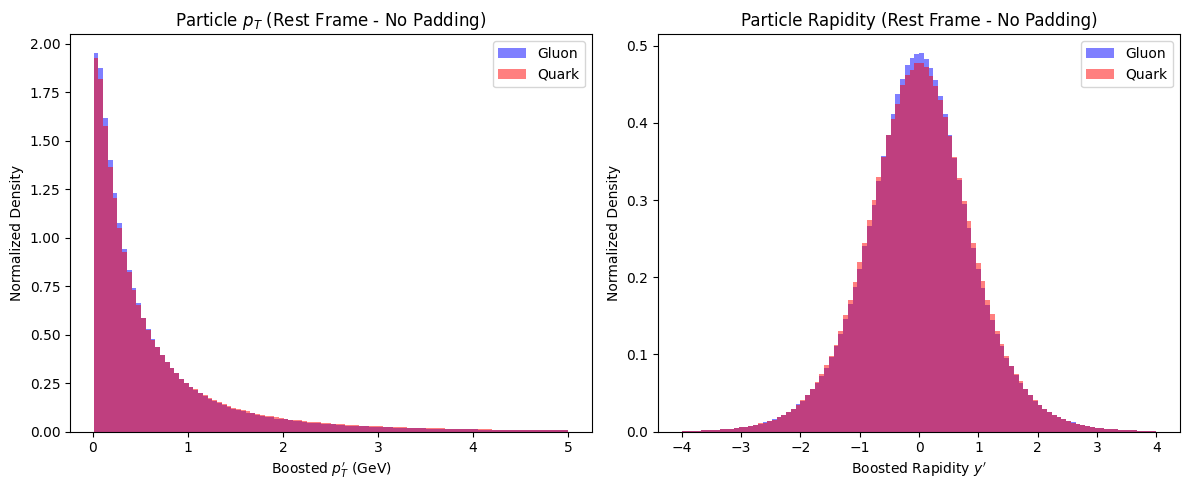

In [20]:
import matplotlib.pyplot as plt

# Create a mask to ignore the zero-padded particles
mask_g = pt_boosted[y == 0] > 1e-3
mask_q = pt_boosted[y == 1] > 1e-3

plt.figure(figsize=(12, 5))

# Plot Boosted pT (Filtered)
plt.subplot(1, 2, 1)
plt.hist(pt_boosted[y == 0][mask_g], bins=100, range=(0.01, 5), alpha=0.5, label='Gluon', color='blue', density=True)
plt.hist(pt_boosted[y == 1][mask_q], bins=100, range=(0.01, 5), alpha=0.5, label='Quark', color='red', density=True)
plt.xlabel("Boosted $p_T'$ (GeV)")
plt.ylabel("Normalized Density")
plt.title("Particle $p_T$ (Rest Frame - No Padding)")
plt.legend()

# Plot Boosted Rapidity (Filtered)
plt.subplot(1, 2, 2)
plt.hist(y_boosted[y == 0][mask_g], bins=100, range=(-4, 4), alpha=0.5, label='Gluon', color='blue', density=True)
plt.hist(y_boosted[y == 1][mask_q], bins=100, range=(-4, 4), alpha=0.5, label='Quark', color='red', density=True)
plt.xlabel("Boosted Rapidity $y'$")
plt.ylabel("Normalized Density")
plt.title("Particle Rapidity (Rest Frame - No Padding)")
plt.legend()

plt.tight_layout()
plt.show()